# CNN + Transfer Learning — Fruit Freshness Classification (Fresh vs Rotten)

### Taller de Redes Neuronales

**Tema:** Clasificación del estado de frescura de frutas mediante Redes Neuronales Convolucionales (CNN) y Transfer Learning.

### **Introducción**

En este trabajo se adapta el pipeline de CNN y Transfer Learning desarrollado en el taller a un problema de visión por computadora relacionado con la clasificación de frutas. Se utiliza un dataset de Kaggle que contiene imágenes de **manzanas, plátanos y fresas**, clasificadas como **Fresh** o **Rotten**. El objetivo del modelo será identificar el estado de frescura de la fruta a partir de su imagen.

### **Justificación**

Se eligió este problema porque es fácil de interpretar y permite relacionar la visión por computadora con una aplicación práctica de **inspección y control de calidad de alimentos**. Además, al utilizar un dataset externo en lugar de `medmnist`, fue necesario adaptar el pipeline trabajado en clase al nuevo conjunto de imágenes y construir el proceso de preparación de datos para PyTorch.

Este dataset también permite experimentar con los diferentes aspectos planteados en el taller, como cambios en la arquitectura, *learning rate*, *scheduler*, *data augmentation* y Transfer Learning con ResNet18.

### **Objetivo**

Desarrollar y evaluar modelos de CNN para clasificar imágenes de frutas como **Fresh** o **Rotten**, analizando cómo diferentes configuraciones de entrenamiento y Transfer Learning afectan su desempeño.


### **Ejercicios desarrollados**

1. Cambiar la arquitectura de la CNN mediante BatchNorm, Dropout y más filtros.
2. Experimentar con learning rate y scheduler.
3. Analizar el impacto del data augmentation.
4. La guía propone cambiar el dataset dentro de medmnist. En este trabajo, el cambio se realizó desde el inicio utilizando un dataset no médico descargado desde Kaggle, con imágenes de frutas clasificadas como Fresh y Rotten.
Por ello, todo el pipeline se adapta a este nuevo dataset y el objetivo del ejercicio queda cubierto sin utilizar un segundo dataset.
5. Implementar calibración de probabilidades y curvas ROC.


## 1. ¿Qué es una CNN y por qué se usa en este problema?

Una **CNN** es un tipo de red neuronal diseñada para trabajar con datos que tienen estructura espacial, como imágenes. En una imagen, los píxeles cercanos suelen estar relacionados (bordes, texturas, formas); las CNN explotan esta propiedad mediante **convoluciones**, filtros aprendibles que se deslizan por la imagen para detectar patrones.

**Componentes clave**

**(a) Convolución (Conv2D)**
- Aplica filtros (kernels) para obtener mapas de características.
- Aprende detectores de bordes, texturas y estructuras más complejas en capas profundas.

**(b) Activación (ReLU)**
- Introduce no linealidad.
- ReLU(x) = max(0, x) suele funcionar muy bien.

**(c) Pooling (MaxPool)**
- Reduce resolución espacial, mantiene información importante.
- Ayuda a generalización y reduce costo computacional.

**(d) Capas fully-connected (densas):**
- Integran la información para la clasificación final (Fresh / Rotten).


### **1.2.¿Por qué CNN para este problema?**
La frescura de una fruta se refleja en patrones visuales sutiles (manchas, cambios de textura y color, arrugas en la cáscara). Una CNN puede aprender estas representaciones de forma jerárquica sin tener que diseñar manualmente reglas de color o textura. Además, con **transfer learning** (ResNet18 preentrenada en ImageNet) se puede aprovechar conocimiento visual general para mejorar el desempeño con un dataset relativamente pequeño (522 imágenes únicas).


## 2. Preparación del entorno

Usaremos **PyTorch** para construir y entrenar los modelos. A diferencia de la guía original, en este trabajo se utiliza un dataset de imágenes descargado desde **Kaggle**, por lo que se reemplaza `medmnist` por las herramientas necesarias para trabajar con este dataset.


In [1]:
import sys
import subprocess

packages = [
    "torch",
    "torchvision",
    "kagglehub",
    "numpy",
    "matplotlib",
    "scikit-learn",
    "tqdm"
]

for p in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

In [2]:

!pip -q install kagglehub scikit-learn seaborn

import random
import copy
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from torchvision.models import ResNet18_Weights

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, precision_recall_fscore_support,
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, auc
)
from sklearn.calibration import calibration_curve

from tqdm.auto import tqdm

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

print('PyTorch:', torch.__version__)
print('Dispositivo:', device)

PyTorch: 2.11.0+cu128
Dispositivo: cuda


## 3. Cargar el dataset

El dataset contiene imágenes de **manzanas, plátanos y fresas**, clasificadas según su estado de frescura: **Fresh** y **Rotten**. Se descarga desde Kaggle y se prepara para su posterior uso con PyTorch.

### 3.1. Descarga desde Kaggle

In [3]:
import kagglehub
from pathlib import Path

path = kagglehub.dataset_download(
    "abdulrafeyyashir/fresh-vs-rotten-fruit-images"
)

DATASET_ROOT = Path(path) / "Fruit Freshness Dataset" / "Fruit Freshness Dataset"

print("DATASET_ROOT:", DATASET_ROOT)
print("Contenido:", [p.name for p in DATASET_ROOT.iterdir()])

100%|██████████| 38.5M/38.5M [00:02<00:00, 13.5MB/s]

Extracting files...


DATASET_ROOT: /root/.cache/kagglehub/datasets/abdulrafeyyashir/fresh-vs-rotten-fruit-images/versions/4/Fruit Freshness Dataset/Fruit Freshness Dataset
Contenido: ['Banana', 'Strawberry', 'Apple']


In [4]:
print("DATASET_ROOT:", DATASET_ROOT)
print("\nContenido:")

for p in DATASET_ROOT.iterdir():
    print(p)

DATASET_ROOT: /root/.cache/kagglehub/datasets/abdulrafeyyashir/fresh-vs-rotten-fruit-images/versions/4/Fruit Freshness Dataset/Fruit Freshness Dataset

Contenido:
/root/.cache/kagglehub/datasets/abdulrafeyyashir/fresh-vs-rotten-fruit-images/versions/4/Fruit Freshness Dataset/Fruit Freshness Dataset/Banana
/root/.cache/kagglehub/datasets/abdulrafeyyashir/fresh-vs-rotten-fruit-images/versions/4/Fruit Freshness Dataset/Fruit Freshness Dataset/Strawberry
/root/.cache/kagglehub/datasets/abdulrafeyyashir/fresh-vs-rotten-fruit-images/versions/4/Fruit Freshness Dataset/Fruit Freshness Dataset/Apple


### 3.2. Crear el registro de imágenes

In [5]:
import hashlib

VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.webp', '.jfif'}
records = []

for fruit_dir in sorted([p for p in DATASET_ROOT.iterdir() if p.is_dir()]):
    for freshness in ['Fresh', 'Rotten']:
        class_dir = fruit_dir / freshness

        if not class_dir.exists():
            continue

        for img_path in class_dir.rglob('*'):
            if img_path.is_file() and img_path.suffix.lower() in VALID_EXTENSIONS:

                with open(img_path, 'rb') as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()

                records.append({
                    'path': str(img_path),
                    'fruit': fruit_dir.name,
                    'freshness': freshness,
                    'hash': file_hash
                })

df = pd.DataFrame(records)

print('Imágenes encontradas:', len(df))

print('\nPor fruta y estado:')
print(pd.crosstab(df['fruit'], df['freshness']))

print('\nExtensiones:')
print(
    df['path']
    .str.lower()
    .str.extract(r'(\.[^.]+)$')[0]
    .value_counts()
)

Imágenes encontradas: 566

Por fruta y estado:
freshness   Fresh  Rotten
fruit                    
Apple         124      55
Banana         33      90
Strawberry    220      44

Extensiones:
0
.jpg     519
.jfif     20
.webp     17
.png      10
Name: count, dtype: int64


El desbalance no es igual para las tres frutas: en manzana y fresa predominan las frescas (124 vs 55, y 220 vs 44), pero en plátano ocurre lo contrario, hay casi el triple de podridas que frescas (90 vs 33). Esto importa porque un modelo que aprenda "atajos" específicos de una fruta podría fallar al generalizar a otra, algo a tener en cuenta al interpretar los errores más adelante.

### 3.3. Eliminar copias exactas (data leakage)

In [6]:

before = len(df)

df_unique = df.drop_duplicates(
    subset='hash'
).reset_index(drop=True)

removed = before - len(df_unique)

print(f'Imágenes originales: {before}')
print(f'Imágenes únicas por contenido: {len(df_unique)}')
print(f'Copias exactas eliminadas del análisis: {removed}')

print('\nDistribución final:')
print(pd.crosstab(df_unique['fruit'], df_unique['freshness']))

Imágenes originales: 566
Imágenes únicas por contenido: 522
Copias exactas eliminadas del análisis: 44

Distribución final:
freshness   Fresh  Rotten
fruit                    
Apple         115      55
Banana         33      83
Strawberry    192      44


### 3.4. Visualizar ejemplos

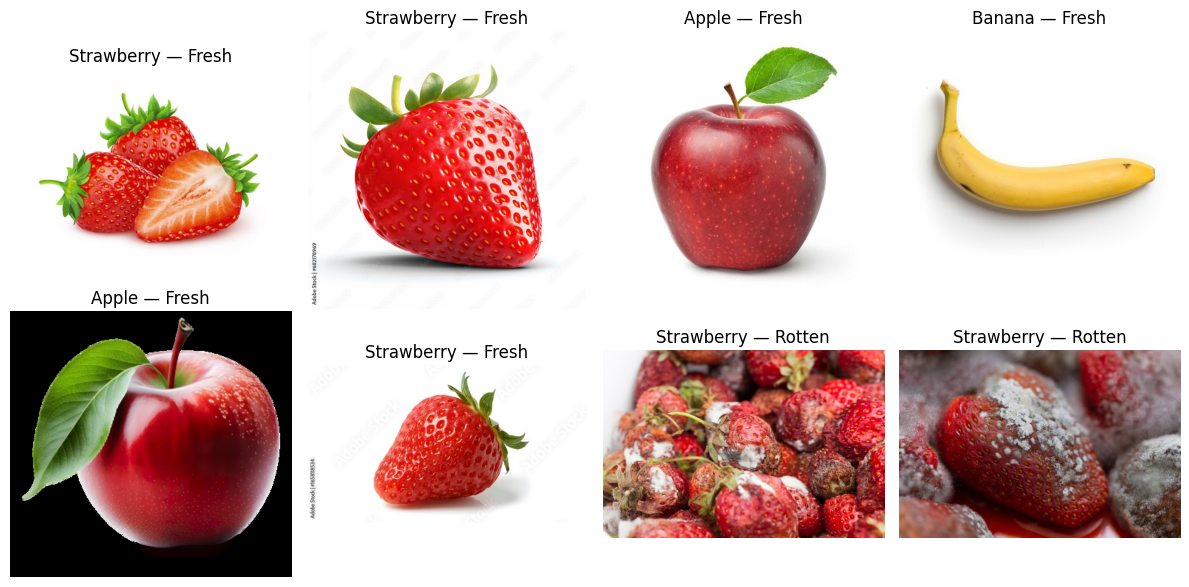

In [7]:
fig, axes = plt.subplots(2, 4, figsize=(12, 6))
sample_df = df_unique.sample(min(8, len(df_unique)), random_state=SEED)

for ax, (_, row) in zip(axes.flat, sample_df.iterrows()):
    img = Image.open(row['path']).convert('RGB')
    ax.imshow(img)
    ax.set_title(f"{row['fruit']} — {row['freshness']}")
    ax.axis('off')

for ax in axes.flat[len(sample_df):]:
    ax.axis('off')

plt.tight_layout()
plt.show()

## 4. Preparar DataLoaders y device

### 4.1. División train / validation / test

In [8]:
train_df, temp_df = train_test_split(
    df_unique,
    test_size=0.30,
    stratify=df_unique['freshness'],
    random_state=SEED
)

val_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['freshness'],
    random_state=SEED
)

for part in [train_df, val_df, test_df]:
    part.reset_index(drop=True, inplace=True)

print('Train:', len(train_df))
print('Validation:', len(val_df))
print('Test:', len(test_df))

print('\nDistribución Fresh/Rotten:')
print('\nTrain:')
print(train_df['freshness'].value_counts())

print('\nValidation:')
print(val_df['freshness'].value_counts())

print('\nTest:')
print(test_df['freshness'].value_counts())

Train: 365
Validation: 78
Test: 79

Distribución Fresh/Rotten:

Train:
freshness
Fresh     238
Rotten    127
Name: count, dtype: int64

Validation:
freshness
Fresh     51
Rotten    27
Name: count, dtype: int64

Test:
freshness
Fresh     51
Rotten    28
Name: count, dtype: int64


Con un test de apenas 79 imágenes (28 Rotten), cada imagen mal clasificada mueve el accuracy final en poco más de un punto porcentual. Esto explica en parte por qué las métricas varían bastante entre experimentos (CNN base, augmentation, learning rate, etc.): con una muestra tan chica hay más variabilidad "por azar" de la que habría con miles de imágenes.

### 4.2. Dataset personalizado y DataLoaders

In [9]:
IMAGE_SIZE = 128
BATCH_SIZE = 32
NUM_WORKERS = 2 if torch.cuda.is_available() else 0

class FruitFreshnessDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df = dataframe.reset_index(drop=True)
        self.transform = transform
        self.class_to_idx = {'Fresh': 0, 'Rotten': 1}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        if self.transform:
            image = self.transform(image)
        label = self.class_to_idx[row['freshness']]
        return image, label

normalize = transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)

transform_basic = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    normalize
])

train_ds = FruitFreshnessDataset(train_df, transform_basic)
val_ds = FruitFreshnessDataset(val_df, transform_basic)
test_ds = FruitFreshnessDataset(test_df, transform_basic)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

class_names = ['Fresh', 'Rotten']
num_classes = 2

print('Clases:', class_names)
print('Batches de entrenamiento:', len(train_loader))

Clases: ['Fresh', 'Rotten']
Batches de entrenamiento: 12


## 5. Modelo 1: CNN entrenada desde cero

La primera CNN se construye desde cero siguiendo el flujo trabajado en clase: convolución → activación ReLU → pooling → clasificación.

In [10]:


class SimpleCNN(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2),
        )
        self.classifier = nn.Sequential(
            nn.AdaptiveAvgPool2d((1, 1)),
            nn.Flatten(),
            nn.Linear(64, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model_base = SimpleCNN(num_classes).to(device)
print(model_base)

SimpleCNN(
  (features): Sequential(
    (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU()
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU()
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU()
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): AdaptiveAvgPool2d(output_size=(1, 1))
    (1): Flatten(start_dim=1, end_dim=-1)
    (2): Linear(in_features=64, out_features=2, bias=True)
  )
)


### 5.1. Funciones de entrenamiento y evaluación

In [11]:
def run_epoch(model, loader, criterion, optimizer=None):

    is_train = optimizer is not None
    if is_train:
        model.train()
    else:
        model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.set_grad_enabled(is_train):
        for images, labels in loader:
            images = images.to(device)
            labels = labels.to(device)

            if is_train:
                optimizer.zero_grad()

            outputs = model(images)
            loss = criterion(outputs, labels)

            if is_train:
                loss.backward()
                optimizer.step()

            running_loss += loss.item() * labels.size(0)
            preds = outputs.argmax(dim=1)
            correct += (preds == labels).sum().item()
            total += labels.size(0)

    return running_loss / total, correct / total


def predict_model(model, loader):

    model.eval()
    y_true = []
    y_pred = []
    y_prob = []

    with torch.no_grad():

        for images, labels in loader:
            images = images.to(device)
            logits = model(images)
            probs = torch.softmax(
                logits,
                dim=1
            ).cpu().numpy()
            preds = probs.argmax(axis=1)
            y_true.extend(labels.numpy())
            y_pred.extend(preds)
            y_prob.extend(probs)

    return (
        np.array(y_true),
        np.array(y_pred),
        np.array(y_prob)
    )

### 5.2. Entrenar el modelo desde cero

In [12]:

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(
    model_base.parameters(),
    lr=1e-3
)

epochs = 8
history_base = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, epochs + 1):

    # Entrenamiento
    train_loss, train_acc = run_epoch(
        model_base,
        train_loader,
        criterion,
        optimizer
    )

    # Validación
    val_loss, val_acc = run_epoch(
        model_base,
        val_loader,
        criterion
    )

    history_base["train_loss"].append(train_loss)
    history_base["train_acc"].append(train_acc)
    history_base["val_loss"].append(val_loss)
    history_base["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")

Epoch 01 | train_loss=0.6331 | train_acc=0.6356 | val_loss=0.5954 | val_acc=0.6538
Epoch 02 | train_loss=0.5750 | train_acc=0.7068 | val_loss=0.5444 | val_acc=0.7308
Epoch 03 | train_loss=0.5357 | train_acc=0.7479 | val_loss=0.4829 | val_acc=0.7949
Epoch 04 | train_loss=0.5216 | train_acc=0.7836 | val_loss=0.4379 | val_acc=0.7692
Epoch 05 | train_loss=0.4989 | train_acc=0.7863 | val_loss=0.4268 | val_acc=0.7949
Epoch 06 | train_loss=0.5022 | train_acc=0.7863 | val_loss=0.4609 | val_acc=0.8846
Epoch 07 | train_loss=0.4809 | train_acc=0.7973 | val_loss=0.3819 | val_acc=0.8590
Epoch 08 | train_loss=0.4637 | train_acc=0.8274 | val_loss=0.3703 | val_acc=0.7692


### 5.3. Curvas de entrenamiento

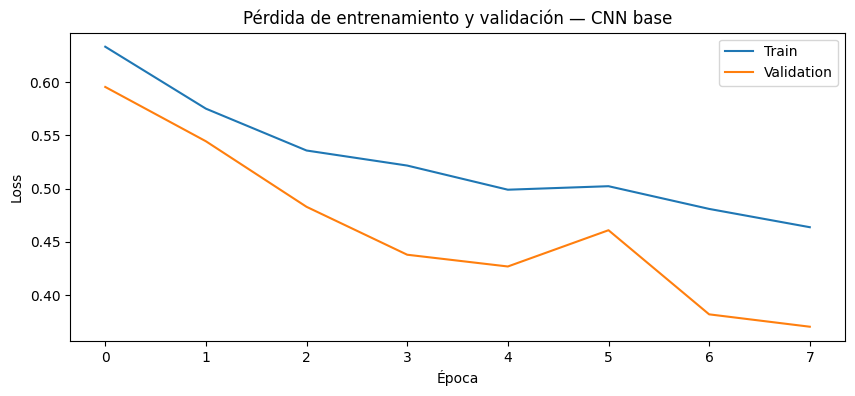

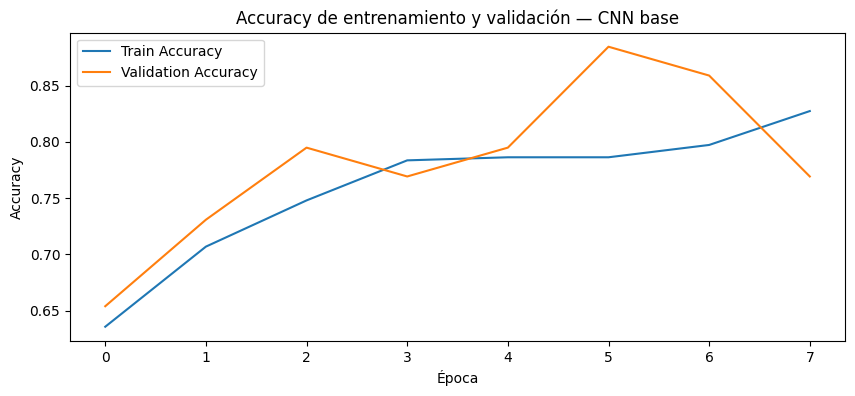

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(history_base["train_loss"],label="Train")
plt.plot(history_base["val_loss"],label="Validation")
plt.title("Pérdida de entrenamiento y validación — CNN base")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_base["train_acc"],label="Train Accuracy")
plt.plot(history_base["val_acc"],label="Validation Accuracy")
plt.title("Accuracy de entrenamiento y validación — CNN base")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

**Observación:**

La validación sube de forma irregular hasta un pico de ~0.89 en la
época 6, pero cae en las últimas dos y cierra en ~0.77, por debajo incluso del train. El loss, en cambio, sigue
bajando hasta el final, así que probablemente sea más ruido de un set de validación chico (78 imágenes) que un
sobreajuste real. Esto calza con el resultado en test de esta corrida (accuracy=0.7468), más bajo que en corridas
anteriores.

### 5.4. Evaluación final en test

In [14]:
y_true, y_pred, y_prob = predict_model(model_base,test_loader)
accuracy = accuracy_score(y_true,y_pred)
roc_auc = roc_auc_score(y_true,y_prob[:, 1])

print(f"Test Accuracy: {accuracy:.4f}")
print(f"Test ROC-AUC:  {roc_auc:.4f}")

print("\nClassification Report:")
print(classification_report(y_true,y_pred,target_names=class_names,digits=4))

cm = confusion_matrix(y_true,y_pred)

print("\nMatriz de confusión:")
print(cm)

result_base = {"modelo": "CNN base", "accuracy": accuracy, "roc_auc": roc_auc}


Test Accuracy: 0.7468
Test ROC-AUC:  0.8109

Classification Report:
              precision    recall  f1-score   support

       Fresh     0.7246    0.9804    0.8333        51
      Rotten     0.9000    0.3214    0.4737        28

    accuracy                         0.7468        79
   macro avg     0.8123    0.6509    0.6535        79
weighted avg     0.7868    0.7468    0.7059        79


Matriz de confusión:
[[50  1]
 [19  9]]


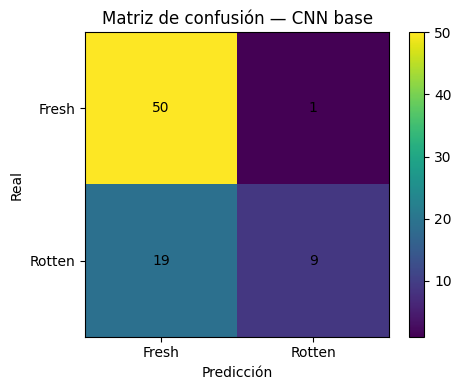

In [15]:
plt.figure(figsize=(5, 4))
plt.imshow(cm)
plt.title("Matriz de confusión — CNN base")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.xticks([0, 1],class_names)
plt.yticks([0, 1],class_names)

for i in range(2):
    for j in range(2):
        plt.text(j,i,cm[i, j],ha="center",va="center")

plt.colorbar()
plt.tight_layout()
plt.show()

**Observación:**

Test Accuracy=0.7468, ROC-AUC=0.8109. El modelo detecta casi toda la fruta
fresca (50 de 51), pero le cuesta mucho la podrida: de 28 Rotten, solo acierta en 9 y deja pasar 19 como frescas. En
un caso real de control de calidad esto es relevante, porque ese tipo de error (dejar pasar fruta en mal estado)
suele ser más costoso que el error opuesto.

## 6. Ejercicio 1 — Cambiar la arquitectura de la CNN
El objetivo es observar si una arquitectura más completa cambia el comportamiento de la CNN base.

### 6.1. Arquitectura mejorada

In [16]:

class CNNImproved(nn.Module):
    def __init__(self, num_classes=2):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),

            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((1, 1))
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))

model_improved = CNNImproved(num_classes).to(device)
model_improved


CNNImproved(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (13): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=Tru

### 6.2. Entrenamiento

In [17]:

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_improved.parameters(), lr=1e-3)

epochs = 6
history_improved = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, epochs + 1):
    train_loss, train_acc = run_epoch(model_improved, train_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model_improved, val_loader, criterion)

    history_improved["train_loss"].append(train_loss)
    history_improved["train_acc"].append(train_acc)
    history_improved["val_loss"].append(val_loss)
    history_improved["val_acc"].append(val_acc)

    print(
        f"Epoch {epoch:02d} | "
        f"train_loss={train_loss:.4f} | "
        f"train_acc={train_acc:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_acc={val_acc:.4f}"
    )


Epoch 01 | train_loss=0.5705 | train_acc=0.7479 | val_loss=0.5224 | val_acc=0.6538
Epoch 02 | train_loss=0.4181 | train_acc=0.8658 | val_loss=0.4246 | val_acc=0.7564
Epoch 03 | train_loss=0.4041 | train_acc=0.8493 | val_loss=0.3071 | val_acc=0.8974
Epoch 04 | train_loss=0.3214 | train_acc=0.9068 | val_loss=0.2189 | val_acc=0.9231
Epoch 05 | train_loss=0.3056 | train_acc=0.8986 | val_loss=0.2519 | val_acc=0.9103
Epoch 06 | train_loss=0.2930 | train_acc=0.9068 | val_loss=0.4452 | val_acc=0.8462


### 6.3. Curvas de entrenamiento

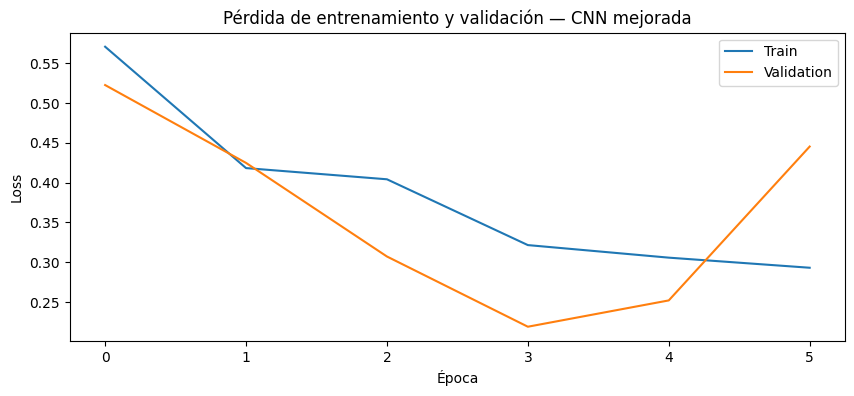

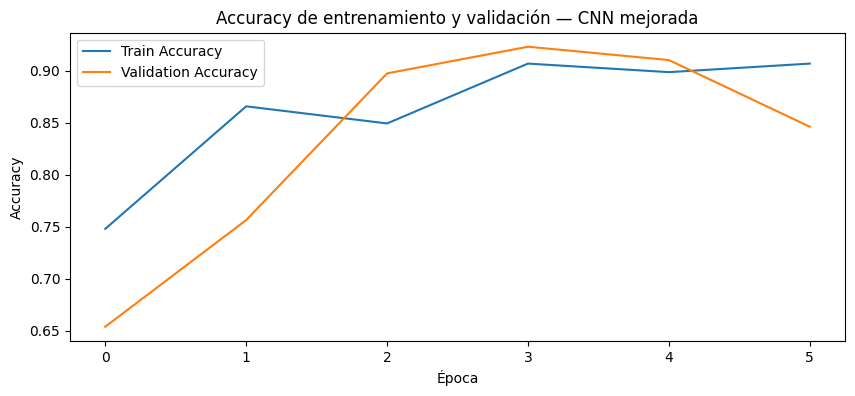

In [18]:

plt.figure(figsize=(10, 4))
plt.plot(history_improved["train_loss"], label="Train")
plt.plot(history_improved["val_loss"], label="Validation")
plt.title("Pérdida de entrenamiento y validación — CNN mejorada")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_improved["train_acc"], label="Train Accuracy")
plt.plot(history_improved["val_acc"], label="Validation Accuracy")
plt.title("Accuracy de entrenamiento y validación — CNN mejorada")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### 6.4. Evaluación final en test

In [19]:
# EVALUACIÓN FINAL EN TEST — CNN MEJORADA

y_true_improved, y_pred_improved, y_prob_improved = predict_model(model_improved, test_loader)

acc_improved = accuracy_score(y_true_improved, y_pred_improved)
auc_improved = roc_auc_score(y_true_improved, y_prob_improved[:, 1])

print(f"Test Accuracy: {acc_improved:.4f}")
print(f"Test ROC-AUC:  {auc_improved:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_improved, y_pred_improved, target_names=class_names, digits=4))

result_improved = {
    "modelo": "CNN mejorada (BatchNorm+Dropout)",
    "accuracy": acc_improved,
    "roc_auc": auc_improved
}


Test Accuracy: 0.8228
Test ROC-AUC:  0.9615

Classification Report:
              precision    recall  f1-score   support

       Fresh     1.0000    0.7255    0.8409        51
      Rotten     0.6667    1.0000    0.8000        28

    accuracy                         0.8228        79
   macro avg     0.8333    0.8627    0.8205        79
weighted avg     0.8819    0.8228    0.8264        79



In [20]:
# COMPARACIÓN RÁPIDA — CNN base vs CNN mejorada
print("Comparación rápida en test:")
print(f"CNN base      | acc={accuracy:.4f} | auc={roc_auc:.4f}")
print(f"CNN mejorada  | acc={acc_improved:.4f} | auc={auc_improved:.4f}")

Comparación rápida en test:
CNN base      | acc=0.7468 | auc=0.8109
CNN mejorada  | acc=0.8228 | auc=0.9615


**Observación :**

BatchNorm, Dropout y más filtros mejoran ambas métricas (acc=0.8228 vs
0.7468, auc=0.9615 vs 0.8109). El modelo mejorado detecta el 100% de la fruta podrida (recall Rotten=1.00), pero a
cambio marca como podridas 14 de las 51 frutas frescas (recall Fresh=0.7255). Para control de calidad esto es un
comportamiento más conservador que prefiere botar fruta buena antes que dejar pasar fruta mala, lo cual suele ser
preferible en ese contexto.

## 7. Ejercicio 2 — Learning rate y scheduler

Se comparan dos tasas de aprendizaje. Para una de ellas se utiliza `ReduceLROnPlateau`, que reduce el learning rate cuando la pérdida de validación deja de mejorar.

Para no sobrecargar mi Colab, cada experimento lo ejecutare durante pocas épocas.

### 7.1. Learning rate 1e-3

In [21]:
# LEARNING RATE 1: lr = 1e-3 (con ReduceLROnPlateau)

model_lr1 = SimpleCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer_lr1 = torch.optim.Adam(model_lr1.parameters(), lr=1e-3)
scheduler_lr1 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lr1, mode='min', factor=0.5, patience=1
)

epochs = 4
history_lr1 = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

for epoch in range(1, epochs + 1):
    train_loss, train_acc = run_epoch(model_lr1, train_loader, criterion, optimizer_lr1)
    val_loss, val_acc = run_epoch(model_lr1, val_loader, criterion)
    scheduler_lr1.step(val_loss)
    current_lr = optimizer_lr1.param_groups[0]['lr']

    history_lr1["train_loss"].append(train_loss)
    history_lr1["train_acc"].append(train_acc)
    history_lr1["val_loss"].append(val_loss)
    history_lr1["val_acc"].append(val_acc)
    history_lr1["lr"].append(current_lr)

    print(
        f"[lr inicial=1e-3] Epoch {epoch:02d} | "
        f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | lr_actual={current_lr:.2e}"
    )


[lr inicial=1e-3] Epoch 01 | train_acc=0.6712 | val_acc=0.6667 | lr_actual=1.00e-03
[lr inicial=1e-3] Epoch 02 | train_acc=0.7151 | val_acc=0.6795 | lr_actual=1.00e-03
[lr inicial=1e-3] Epoch 03 | train_acc=0.7288 | val_acc=0.7821 | lr_actual=1.00e-03
[lr inicial=1e-3] Epoch 04 | train_acc=0.7370 | val_acc=0.7821 | lr_actual=1.00e-03


### 7.2. Learning rate 1e-4

In [22]:
# LEARNING RATE 2: lr = 1e-4 (con ReduceLROnPlateau)

model_lr2 = SimpleCNN(num_classes).to(device)
optimizer_lr2 = torch.optim.Adam(model_lr2.parameters(), lr=1e-4)
scheduler_lr2 = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_lr2, mode='min', factor=0.5, patience=1
)

history_lr2 = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": [], "lr": []}

for epoch in range(1, epochs + 1):
    train_loss, train_acc = run_epoch(model_lr2, train_loader, criterion, optimizer_lr2)
    val_loss, val_acc = run_epoch(model_lr2, val_loader, criterion)
    scheduler_lr2.step(val_loss)
    current_lr = optimizer_lr2.param_groups[0]['lr']

    history_lr2["train_loss"].append(train_loss)
    history_lr2["train_acc"].append(train_acc)
    history_lr2["val_loss"].append(val_loss)
    history_lr2["val_acc"].append(val_acc)
    history_lr2["lr"].append(current_lr)

    print(
        f"[lr inicial=1e-4] Epoch {epoch:02d} | "
        f"train_acc={train_acc:.4f} | val_acc={val_acc:.4f} | lr_actual={current_lr:.2e}"
    )


[lr inicial=1e-4] Epoch 01 | train_acc=0.4767 | val_acc=0.6667 | lr_actual=1.00e-04
[lr inicial=1e-4] Epoch 02 | train_acc=0.6658 | val_acc=0.6538 | lr_actual=1.00e-04
[lr inicial=1e-4] Epoch 03 | train_acc=0.6521 | val_acc=0.6538 | lr_actual=1.00e-04
[lr inicial=1e-4] Epoch 04 | train_acc=0.6575 | val_acc=0.6538 | lr_actual=1.00e-04


### 7.3. Curvas comparativas

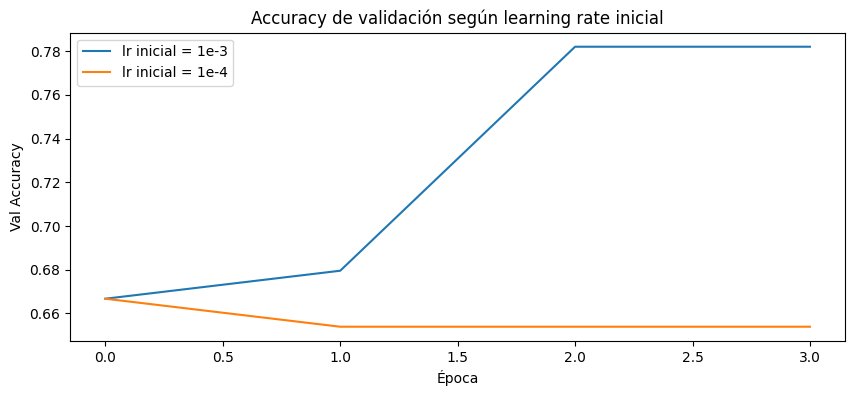

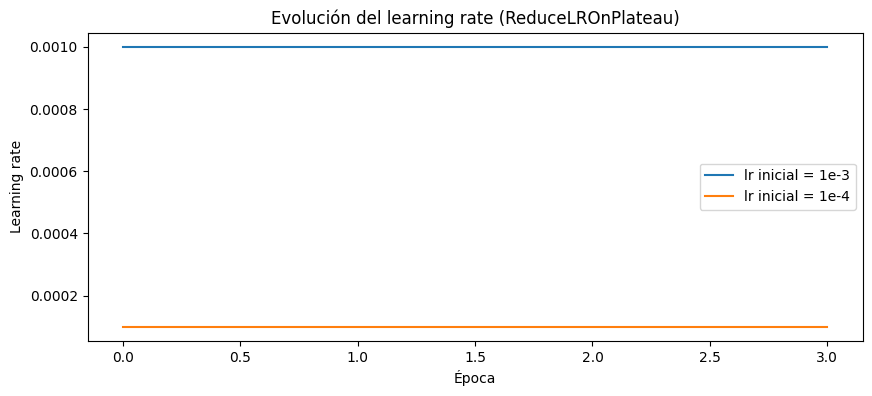

In [23]:
# CURVAS COMPARATIVAS — LEARNING RATE

plt.figure(figsize=(10, 4))
plt.plot(history_lr1["val_acc"], label="lr inicial = 1e-3")
plt.plot(history_lr2["val_acc"], label="lr inicial = 1e-4")
plt.title("Accuracy de validación según learning rate inicial")
plt.xlabel("Época")
plt.ylabel("Val Accuracy")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_lr1["lr"], label="lr inicial = 1e-3")
plt.plot(history_lr2["lr"], label="lr inicial = 1e-4")
plt.title("Evolución del learning rate (ReduceLROnPlateau)")
plt.xlabel("Época")
plt.ylabel("Learning rate")
plt.legend()
plt.show()


### 7.4. Evaluación final en test

In [24]:
# EVALUACIÓN FINAL EN TEST — COMPARACIÓN DE LEARNING RATE

resultados_lr = []

for nombre, modelo in [("CNN base — lr=1e-3", model_lr1), ("CNN base — lr=1e-4", model_lr2)]:
    y_true_i, y_pred_i, y_prob_i = predict_model(modelo, test_loader)
    acc_i = accuracy_score(y_true_i, y_pred_i)
    auc_i = roc_auc_score(y_true_i, y_prob_i[:, 1])

    print(f"{nombre} | Test Accuracy={acc_i:.4f} | Test ROC-AUC={auc_i:.4f}")
    resultados_lr.append({"modelo": nombre, "accuracy": acc_i, "roc_auc": auc_i})


CNN base — lr=1e-3 | Test Accuracy=0.7722 | Test ROC-AUC=0.7962
CNN base — lr=1e-4 | Test Accuracy=0.6582 | Test ROC-AUC=0.7458


Con solo 4 épocas, ambos modelos parten cerca del "sesgo hacia la clase
mayoritaria" (Fresh es ~65% del train, así que ~0.65 de accuracy ya se logra casi sin aprender). lr=1e-3 alcanza
acc=0.7722/auc=0.7962, y lr=1e-4 se queda más atrás en ambas métricas (acc=0.6582/auc=0.7458) el learning rate más
chico sigue siendo el más lento en despegar. En este caso, lr=1e-3 sí logra superar el resultado de la CNN base de
esta corrida (0.7468), aunque con solo 4 épocas la comparación es ajustada.

## 8. Data Augmentation (Ejercicio 3)

Se compara la CNN con las imágenes originales frente a una versión que utiliza pequeñas transformaciones durante el entrenamiento.

Las transformaciones se aplican **solo al entrenamiento**. Validation y Test permanecen sin transformaciones aleatorias.

### 8.1. Transformaciones y ejemplos

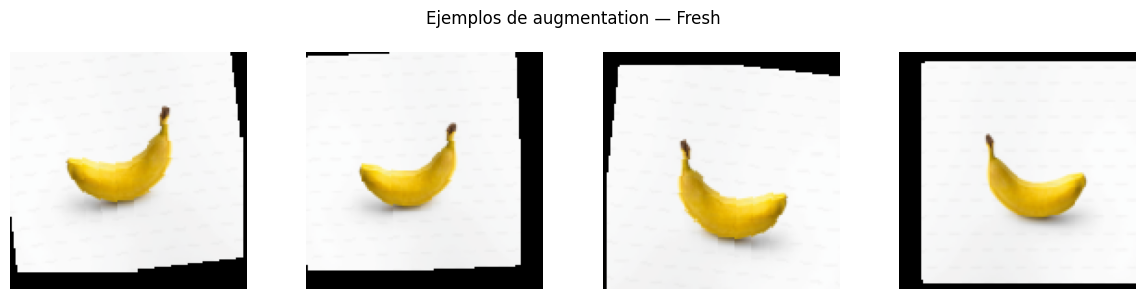

In [25]:

transform_aug = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.RandomAffine(degrees=0, translate=(0.08, 0.08), scale=(0.90, 1.10)),
    transforms.ToTensor(),
    normalize
])

train_aug_ds = FruitFreshnessDataset(train_df, transform_aug)
train_aug_loader = DataLoader(train_aug_ds, batch_size=BATCH_SIZE, shuffle=True,num_workers=NUM_WORKERS, pin_memory=torch.cuda.is_available())

# Visualizar algunas transformaciones
sample_row = train_df.sample(1, random_state=SEED).iloc[0]
img = Image.open(sample_row['path']).convert('RGB')

fig, axes = plt.subplots(1, 4, figsize=(12, 3))
for ax in axes:
    aug_img = train_aug_ds.transform(img).permute(1, 2, 0).numpy()
    aug_img = aug_img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
    aug_img = np.clip(aug_img, 0, 1)
    ax.imshow(aug_img)
    ax.axis('off')
plt.suptitle(f"Ejemplos de augmentation — {sample_row['freshness']}")
plt.tight_layout()
plt.show()

### 8.2. Entrenamiento

In [26]:
# ENTRENAR CNN CON DATA AUGMENTATION

model_aug = SimpleCNN(num_classes).to(device)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_aug.parameters(), lr=1e-3)

epochs = 6
history_aug = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}

for epoch in range(1, epochs + 1):
    train_loss, train_acc = run_epoch(model_aug, train_aug_loader, criterion, optimizer)
    val_loss, val_acc = run_epoch(model_aug, val_loader, criterion)

    history_aug["train_loss"].append(train_loss)
    history_aug["train_acc"].append(train_acc)
    history_aug["val_loss"].append(val_loss)
    history_aug["val_acc"].append(val_acc)

    print(f"Epoch {epoch:02d} |train_loss={train_loss:.4f} | train_acc={train_acc:.4f} | val_loss={val_loss:.4f} | val_acc={val_acc:.4f}")


Epoch 01 |train_loss=0.6403 | train_acc=0.6521 | val_loss=0.6376 | val_acc=0.6538
Epoch 02 |train_loss=0.6119 | train_acc=0.6521 | val_loss=0.6338 | val_acc=0.6538
Epoch 03 |train_loss=0.6110 | train_acc=0.6795 | val_loss=0.6372 | val_acc=0.6538
Epoch 04 |train_loss=0.5874 | train_acc=0.7123 | val_loss=0.6237 | val_acc=0.6538
Epoch 05 |train_loss=0.5601 | train_acc=0.7151 | val_loss=0.5777 | val_acc=0.6667
Epoch 06 |train_loss=0.5280 | train_acc=0.7425 | val_loss=0.4906 | val_acc=0.7051


### 8.3. Curvas de entrenamiento

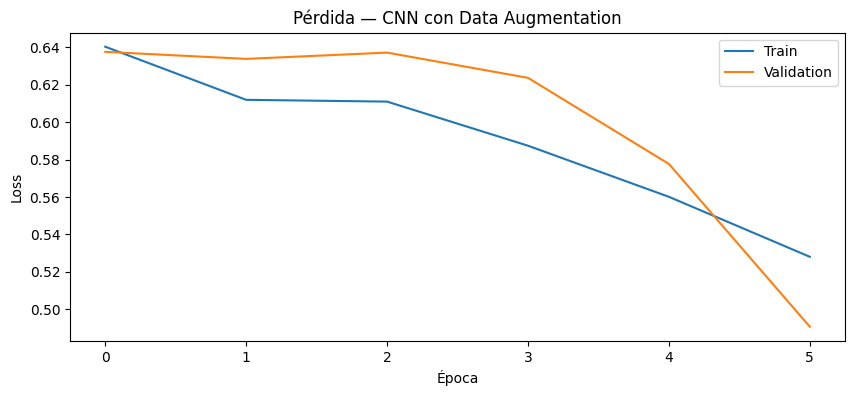

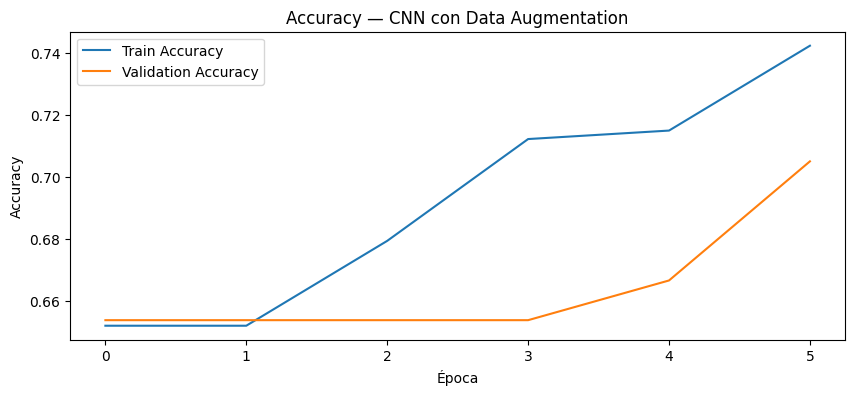

In [27]:
# CURVAS DE ENTRENAMIENTO — CNN CON AUGMENTATION

plt.figure(figsize=(10, 4))
plt.plot(history_aug["train_loss"], label="Train")
plt.plot(history_aug["val_loss"], label="Validation")
plt.title("Pérdida — CNN con Data Augmentation")
plt.xlabel("Época")
plt.ylabel("Loss")
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_aug["train_acc"], label="Train Accuracy")
plt.plot(history_aug["val_acc"], label="Validation Accuracy")
plt.title("Accuracy — CNN con Data Augmentation")
plt.xlabel("Época")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


### 8.4. Evaluación final en test

In [28]:
# EVALUACIÓN FINAL EN TEST — CNN CON AUGMENTATION

y_true_aug, y_pred_aug, y_prob_aug = predict_model(model_aug, test_loader)

acc_aug = accuracy_score(y_true_aug, y_pred_aug)
auc_aug = roc_auc_score(y_true_aug, y_prob_aug[:, 1])

print(f"Test Accuracy: {acc_aug:.4f}")
print(f"Test ROC-AUC:  {auc_aug:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_aug, y_pred_aug, target_names=class_names, digits=4))

result_aug = {
    "modelo": "CNN + Data Augmentation",
    "accuracy": acc_aug,
    "roc_auc": auc_aug
}


Test Accuracy: 0.7468
Test ROC-AUC:  0.8130

Classification Report:
              precision    recall  f1-score   support

       Fresh     0.7246    0.9804    0.8333        51
      Rotten     0.9000    0.3214    0.4737        28

    accuracy                         0.7468        79
   macro avg     0.8123    0.6509    0.6535        79
weighted avg     0.7868    0.7468    0.7059        79



8.5 Comparación rápida

In [29]:
print(f"Sin augmentation  | test_acc={accuracy:.4f} | test_auc={roc_auc:.4f}")
print(f"Con augmentation  | test_acc={acc_aug:.4f} | test_auc={auc_aug:.4f}")

Sin augmentation  | test_acc=0.7468 | test_auc=0.8109
Con augmentation  | test_acc=0.7468 | test_auc=0.8130


**Observación:**

con augmentation el resultado queda prácticamente igual que sin él en
accuracy (0.7468 en ambos casos) y muy similar en ROC-AUC (0.8130 vs 0.8109). En esta corrida, aplicar
transformaciones al entrenamiento no aportó una mejora clara ni tampoco perjudicó al modelo.

## 9. Transfer Learning con ResNet18

Se utiliza una **ResNet18 preentrenada en ImageNet**. Primero se congelan las capas convolucionales y se reemplaza la capa final para las dos categorías del problema.

### 9.1. Construir el modelo preentrenado

In [30]:

weights = ResNet18_Weights.DEFAULT
resnet = models.resnet18(weights=weights)

# Congelar el extractor de características
for param in resnet.parameters():
    param.requires_grad = False

resnet.fc = nn.Linear(resnet.fc.in_features, num_classes)
resnet = resnet.to(device)

criterion = nn.CrossEntropyLoss()
optimizer_ft = optim.Adam(resnet.fc.parameters(), lr=1e-3)

history_tl = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}
best_state = copy.deepcopy(resnet.state_dict())
best_val = -1

for epoch in range(4):
    tr_loss, tr_acc = run_epoch(resnet, train_loader, criterion, optimizer_ft)
    va_loss, va_acc = run_epoch(resnet, val_loader, criterion)

    history_tl['train_loss'].append(tr_loss)
    history_tl['val_loss'].append(va_loss)
    history_tl['train_acc'].append(tr_acc)
    history_tl['val_acc'].append(va_acc)

    if va_acc > best_val:
        best_val = va_acc
        best_state = copy.deepcopy(resnet.state_dict())

    print(f'Transfer Learning | Época {epoch+1}/4 | Train={tr_acc:.4f} | Val={va_acc:.4f}')

resnet.load_state_dict(best_state)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


Transfer Learning | Época 1/4 | Train=0.6932 | Val=0.9103
Transfer Learning | Época 2/4 | Train=0.8740 | Val=0.9615
Transfer Learning | Época 3/4 | Train=0.8986 | Val=1.0000
Transfer Learning | Época 4/4 | Train=0.9260 | Val=1.0000


<All keys matched successfully>

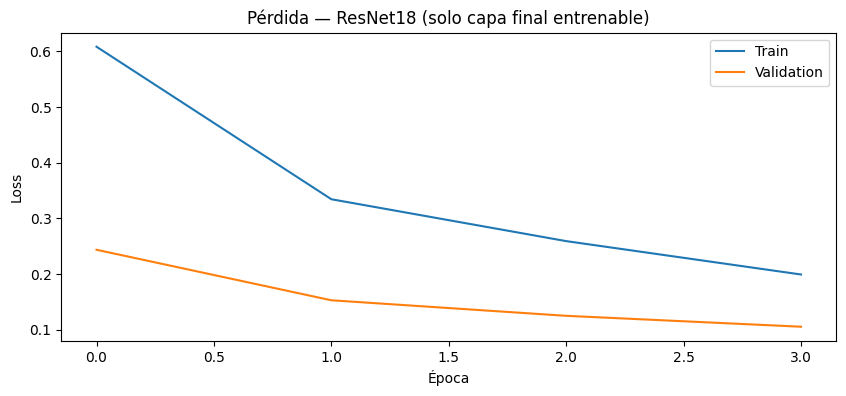

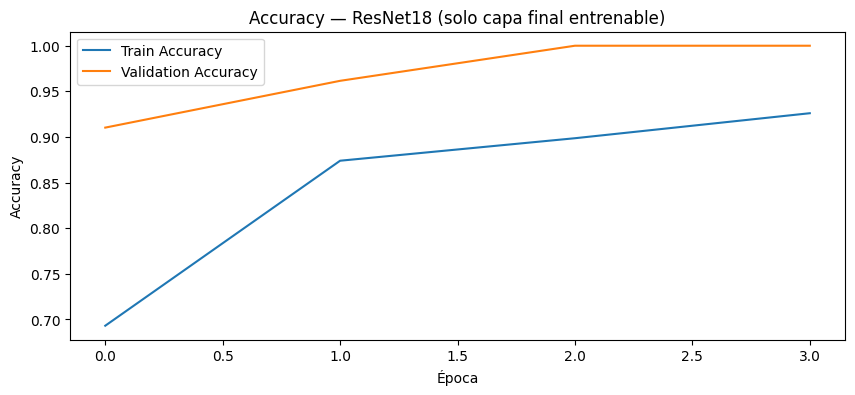

In [31]:
plt.figure(figsize=(10, 4))
plt.plot(history_tl['train_loss'], label='Train')
plt.plot(history_tl['val_loss'], label='Validation')
plt.title('Pérdida — ResNet18 (solo capa final entrenable)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_tl['train_acc'], label='Train Accuracy')
plt.plot(history_tl['val_acc'], label='Validation Accuracy')
plt.title('Accuracy — ResNet18 (solo capa final entrenable)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


### 9.2. Fine-tuning (descongelar capas)

In [32]:

for param in resnet.layer4.parameters():
    param.requires_grad = True

optimizer_ft2 = optim.Adam(
    filter(lambda p: p.requires_grad, resnet.parameters()), lr=1e-4
)

best_state = copy.deepcopy(resnet.state_dict())
best_val = -1
history_ft = {'train_loss': [], 'val_loss': [], 'train_acc': [], 'val_acc': []}

for epoch in range(3):
    tr_loss, tr_acc = run_epoch(resnet, train_loader, criterion, optimizer_ft2)
    va_loss, va_acc = run_epoch(resnet, val_loader, criterion)

    history_ft['train_loss'].append(tr_loss)
    history_ft['val_loss'].append(va_loss)
    history_ft['train_acc'].append(tr_acc)
    history_ft['val_acc'].append(va_acc)

    if va_acc > best_val:
        best_val = va_acc
        best_state = copy.deepcopy(resnet.state_dict())

    print(f'Fine-tuning | Época {epoch+1}/3 | Train={tr_acc:.4f} | Val={va_acc:.4f}')

resnet.load_state_dict(best_state)

Fine-tuning | Época 1/3 | Train=0.9589 | Val=0.9872
Fine-tuning | Época 2/3 | Train=0.9918 | Val=1.0000
Fine-tuning | Época 3/3 | Train=0.9973 | Val=0.9872


<All keys matched successfully>

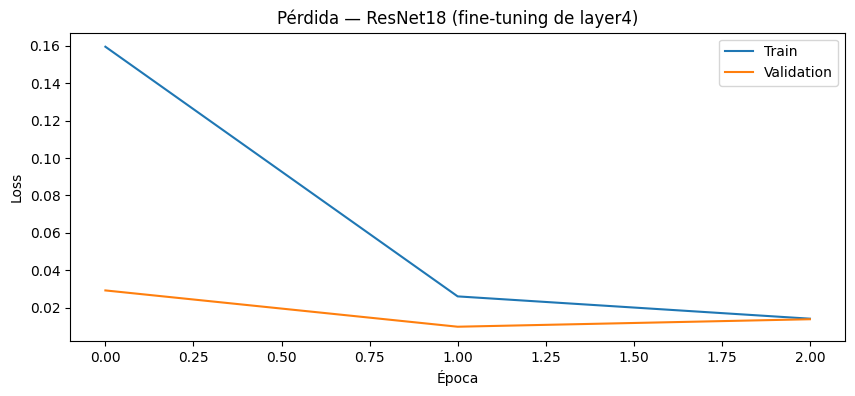

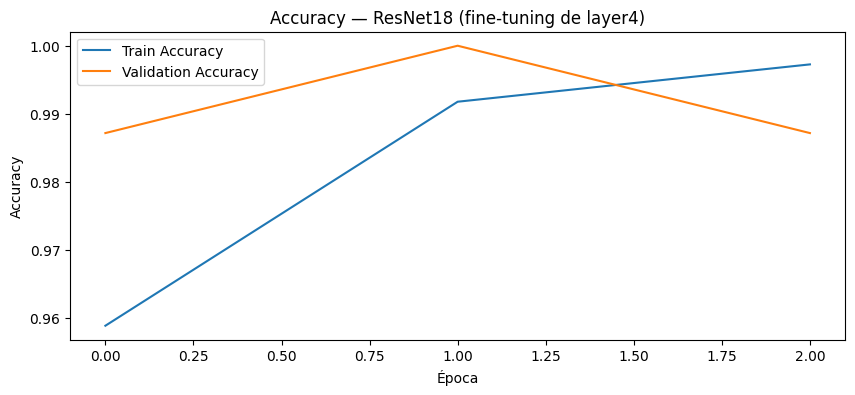

In [33]:

plt.figure(figsize=(10, 4))
plt.plot(history_ft['train_loss'], label='Train')
plt.plot(history_ft['val_loss'], label='Validation')
plt.title('Pérdida — ResNet18 (fine-tuning de layer4)')
plt.xlabel('Época')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(10, 4))
plt.plot(history_ft['train_acc'], label='Train Accuracy')
plt.plot(history_ft['val_acc'], label='Validation Accuracy')
plt.title('Accuracy — ResNet18 (fine-tuning de layer4)')
plt.xlabel('Época')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


### 9.3. Evaluación en test del modelo con transfer learning

In [34]:

y_true_resnet, y_pred_resnet, y_prob_resnet = predict_model(resnet, test_loader)

acc_resnet = accuracy_score(y_true_resnet, y_pred_resnet)
auc_resnet = roc_auc_score(y_true_resnet, y_prob_resnet[:, 1])

print(f"Test Accuracy: {acc_resnet:.4f}")
print(f"Test ROC-AUC:  {auc_resnet:.4f}")

print("\nClassification Report:")
print(classification_report(y_true_resnet, y_pred_resnet, target_names=class_names, digits=4))

result_resnet = {
    "modelo": "ResNet18 (Transfer Learning + Fine-tuning)",
    "accuracy": acc_resnet,
    "roc_auc": auc_resnet
}


Test Accuracy: 1.0000
Test ROC-AUC:  1.0000

Classification Report:
              precision    recall  f1-score   support

       Fresh     1.0000    1.0000    1.0000        51
      Rotten     1.0000    1.0000    1.0000        28

    accuracy                         1.0000        79
   macro avg     1.0000    1.0000    1.0000        79
weighted avg     1.0000    1.0000    1.0000        79



9.4. Comparación global

In [35]:
print("Resumen de resultados en test")
print(f"CNN base                  | acc={accuracy:.4f} | auc={roc_auc:.4f}")
print(f"CNN mejorada (BN+Dropout)  | acc={acc_improved:.4f} | auc={auc_improved:.4f}")
print(f"CNN + Data Augmentation    | acc={acc_aug:.4f} | auc={auc_aug:.4f}")
print(f"Transfer learning (ResNet) | acc={acc_resnet:.4f} | auc={auc_resnet:.4f}")

Resumen de resultados en test
CNN base                  | acc=0.7468 | auc=0.8109
CNN mejorada (BN+Dropout)  | acc=0.8228 | auc=0.9615
CNN + Data Augmentation    | acc=0.7468 | auc=0.8130
Transfer learning (ResNet) | acc=1.0000 | auc=1.0000


**Observación:**

El resumen confirma que Transfer Learning (ResNet18 con fine-tuning) es el mejor modelo con claridad (acc=1.0000,
auc=1.0000), por encima de la CNN mejorada (0.8228/0.9615), la CNN base (0.7468/0.8109) y el augmentation
(0.7468/0.8130).

Tiene sentido: ResNet18 ya "sabe ver" bordes, texturas y formas gracias a ImageNet, y solo necesita adaptar unas
pocas capas a las texturas específicas de fruta fresca vs podrida, algo mucho más fácil que aprender todo desde
cero con apenas 365 imágenes de entrenamiento.

## 10. Ejercicio 5 — Curva ROC y calibración de probabilidades

Como el problema es binario, se puede construir directamente la curva ROC usando la probabilidad de la clase **Rotten**.

### 10.1. Curva ROC

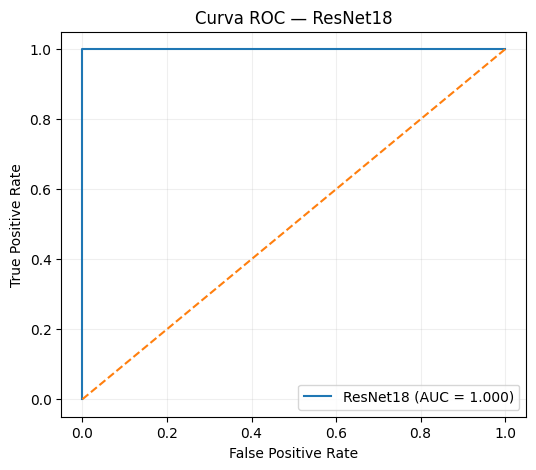

In [36]:

fpr, tpr, thresholds = roc_curve(y_true_resnet, y_prob_resnet[:, 1])
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, label=f'ResNet18 (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC — ResNet18')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

Cuanto más se acerca la curva ROC a la esquina superior izquierda, mejor separa el
modelo las frutas frescas de las podridas en todos los umbrales posibles (no solo en 0.5). Con un AUC de 1.000, la
curva de ResNet18 pega completamente al eje, señal de que el modelo separa perfectamente ambas clases en este
conjunto de test.

### 10.2. Calibración de probabilidades

La calibración permite analizar si la confianza probabilística del modelo es coherente con la frecuencia real de aciertos. Una curva cercana a la diagonal representa una relación más consistente entre probabilidad predicha y frecuencia observada.

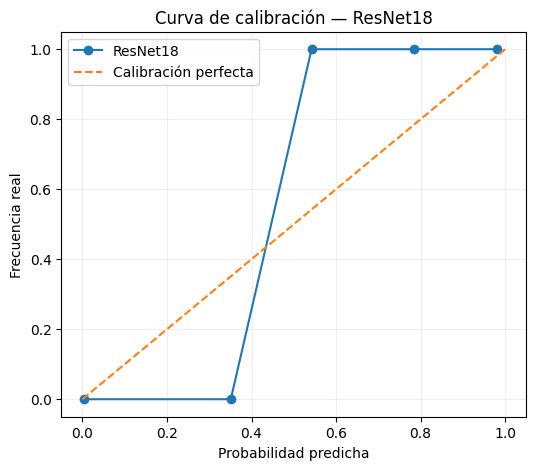

In [37]:

prob_true, prob_pred = calibration_curve(
    y_true_resnet,
    y_prob_resnet[:, 1],
    n_bins=5,
    strategy='uniform'
)

plt.figure(figsize=(6, 5))
plt.plot(prob_pred, prob_true, marker='o', label='ResNet18')
plt.plot([0, 1], [0, 1], linestyle='--', label='Calibración perfecta')
plt.xlabel('Probabilidad predicha')
plt.ylabel('Frecuencia real')
plt.title('Curva de calibración — ResNet18')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

La diagonal representa una calibración perfecta (si el modelo dice "80% de probabilidad
de Rotten", en la realidad debería acertar ~80% de las veces). Acá la curva salta de 0 a 1 de golpe entre 0.4 y 0.55
de probabilidad predicha, en vez de subir gradual: con un AUC de 1.000 el modelo casi no tiene predicciones "a medio
camino" (probabilidades cercanas a 0.5), así que con solo 79 imágenes en 5 bins, ese salto responde más a lo poco
graduales que son las probabilidades del modelo que a un problema real de calibración.


## 11. Comparación general de modelos

In [38]:

all_results = [result_base, result_improved] + resultados_lr + [result_aug, result_resnet]
results_df = pd.DataFrame(all_results)
results_df


,modelo,accuracy,roc_auc
0,CNN base,0.746835,0.810924
1,CNN mejorada (BatchNorm+Dropout),0.822785,0.961485
2,CNN base — lr=1e-3,0.772152,0.796218
3,CNN base — lr=1e-4,0.658228,0.745798
4,CNN + Data Augmentation,0.746835,0.813025
5,ResNet18 (Transfer Learning + Fine-tuning),1.000000,1.000000


ResNet18 con fine-tuning se lleva el primer lugar sin discusión, con un resultado perfecto en test. La CNN mejorada
(BatchNorm+Dropout) también destaca, siendo la segunda mejor opción con clara ventaja sobre la CNN base. Los
experimentos de learning rate y el de data augmentation quedan más cerca del nivel de la CNN base, sin una mejora
clara en esta corrida. Recordando que el test tiene solo 79 imágenes, así que un par de aciertos o
errores de más en Rotten pueden mover el accuracy bastante más de lo que se vería con un dataset grande.

## 12. Interpretabilidad básica: Grad-CAM

Se incluye una implementación sencilla para observar qué regiones de la imagen influyen en la predicción de ResNet18.

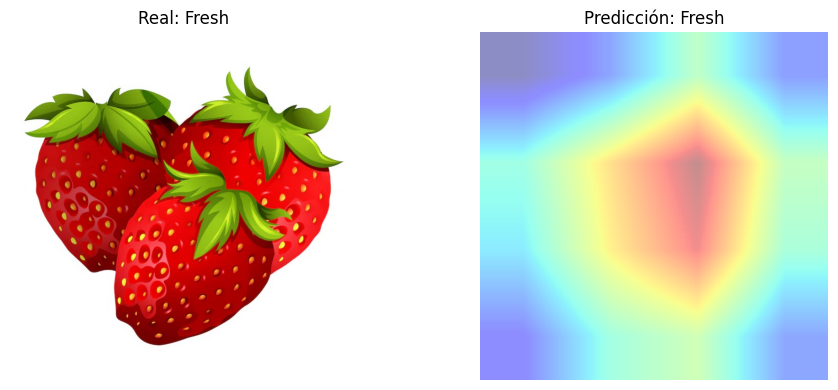

In [39]:
class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None
        self.forward_hook = target_layer.register_forward_hook(self._save_activation)
        self.backward_hook = target_layer.register_full_backward_hook(self._save_gradient)

    def _save_activation(self, module, inp, output):
        self.activations = output.detach()

    def _save_gradient(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def remove(self):
        self.forward_hook.remove()
        self.backward_hook.remove()

    def generate(self, image_tensor, class_idx=None):
        self.model.eval()
        self.model.zero_grad()
        output = self.model(image_tensor)
        if class_idx is None:
            class_idx = output.argmax(dim=1).item()
        output[0, class_idx].backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = (weights * self.activations).sum(dim=1, keepdim=True)
        cam = torch.relu(cam)
        cam = torch.nn.functional.interpolate(
            cam, size=image_tensor.shape[-2:], mode='bilinear', align_corners=False
        )
        cam = cam[0, 0].cpu().numpy()
        cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-8)
        return cam, class_idx

sample = test_df.sample(1, random_state=SEED).iloc[0]
raw_img = Image.open(sample['path']).convert('RGB')
input_tensor = transform_basic(raw_img).unsqueeze(0).to(device)

gradcam = GradCAM(resnet, resnet.layer4[-1].conv2)
cam, pred_class = gradcam.generate(input_tensor)
gradcam.remove()

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.imshow(raw_img)
plt.title(f"Real: {sample['freshness']}")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(raw_img)
plt.imshow(cam, alpha=0.45, cmap='jet')
plt.title(f"Predicción: {class_names[pred_class]}")
plt.axis('off')
plt.tight_layout()
plt.show()

## 13. Guardar y cargar modelos

In [40]:
import os

os.makedirs('/content/models', exist_ok=True)

torch.save(model_base.state_dict(), '/content/models/cnn_base_fruit_freshness.pth')
torch.save(model_improved.state_dict(), '/content/models/cnn_improved_fruit_freshness.pth')
torch.save(model_aug.state_dict(), '/content/models/cnn_aug_fruit_freshness.pth')
torch.save(resnet.state_dict(), '/content/models/resnet18_fruit_freshness.pth')

print('Modelos guardados en /content/models/')


Modelos guardados en /content/models/


## 14. Análisis de los experimentos

Completa esta parte después de ejecutar el notebook.

### 14.1. CNN base vs CNN mejorada

Comparar Accuracy, Precision, Recall y F1 para identificar qué ocurrió al añadir BatchNorm, Dropout y más filtros.

### 14.2. Learning rate y scheduler

Observar la evolución de la pérdida, accuracy y learning rate para identificar si la reducción automática del learning rate ayudó a estabilizar el entrenamiento.

### 14.3. Data augmentation

Comparar la CNN base con la CNN que utiliza augmentation. El efecto debe describirse según los resultados obtenidos en este dataset.

### 14.4. Transfer Learning

Comparar ResNet18 con los modelos entrenados desde cero. Considerar tanto las métricas finales como el comportamiento de entrenamiento y validación.

### 14.5. ROC y calibración

La curva ROC muestra la capacidad de separar Fresh y Rotten a distintos umbrales. La curva de calibración permite estudiar la correspondencia entre confianza predicha y frecuencia real.


## 15. Conclusiones

ResNet18 con fine-tuning fue, sin discusión, el mejor modelo de todos: llegó a acc=1.0000 y auc=1.0000 en test,
gracias a que ya venía con todo lo aprendido de ImageNet y solo necesitó ajustar unas pocas capas. La CNN mejorada
(BatchNorm+Dropout) fue la segunda mejor opción (acc=0.8228, auc=0.9615), con una clara ventaja sobre la CNN base
(acc=0.7468, auc=0.8109).

Los experimentos de learning rate y augmentation no lograron superar a la CNN base en esta corrida: lr=1e-3 quedó
apenas por encima (0.7722) y lr=1e-4 bastante más abajo (0.6582), mientras que el augmentation terminó prácticamente
empatado con la base (0.7468). Más que un problema de la idea en sí, creo que fue falta de tiempo: con tan pocas
imágenes de entrenamiento y solo 4-6 épocas, estas variantes no alcanzaron a mostrar todo su potencial.

Un patrón interesante es que la CNN base y la mejorada se equivocan en direcciones opuestas: la base tiende a dejar
pasar fruta podrida como fresca, mientras que la mejorada hace lo contrario, marca fruta fresca como podrida para
no dejar pasar ninguna podrida. Para control de calidad, ese segundo tipo de error suele ser preferible. La curva ROC
de ResNet18 confirma su desempeño perfecto en este test, mientras que su curva de calibración muestra saltos bruscos
más que una subida gradual, algo esperable en un modelo que casi no da probabilidades "a medio camino" y con un test
de solo 79 imágenes.

Por último, es importante mencionar que estos números pueden variar si se vuelve a ejecutar el notebook completo (el dataset es
chico y hay algo de no determinismo propio de entrenar en GPU), pero las tendencias generales, ResNet18 como mejor
modelo con amplio margen, y la necesidad de más épocas para que las otras variantes muestren su potencial, se
mantienen.
